# Exposure, survey lift and the royalty-relief gate

**Review notebook** for `sponsorship_monetization_v1`. The experiment turns Blinkfire impressions into an adstocked exposure series (used by notebooks 10 and 20), links that exposure to the survey's sponsorship-aware vs unaware lift by FIFA property, derives a property allocation *scenario*, and holds a royalty-relief valuation behind an explicit gate. It follows the human-review standard in `AGENTS.md` and replaces the July Markdown annex for this experiment.

> **Status: valuation blocked.** No monetary value is produced until every required input is approved (section 5.4).

*How to use:* run all cells. Read-only unless `RUN_REBUILD = True`. Narrative numbers are computed from current outputs.

In [1]:
# Setup: read-only by default (AGENTS.md). Nothing below rewrites data unless RUN_REBUILD is True.
RUN_REBUILD = False   # set True only to regenerate the production outputs this notebook reads

import json, os, subprocess, sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "srmp").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from srmp.review import stamp_sources

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (10, 4.2), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

def md(text):
    display(Markdown(text))

def fmt(value, digits=2, signed=False):
    return f"{value:+.{digits}f}" if signed else f"{value:.{digits}f}"

if RUN_REBUILD:  # explicit opt-in: re-runs the experiment (seconds)
    subprocess.run([sys.executable, "-m", "srmp.experiments.sponsorship_monetization_v1"], check=True)

E = "data/curated/experimental/sponsorship_monetization_v1/"
SOURCES = [
    "config/experiments/sponsorship_monetization_v1.yaml", "config/royalty_schedule.yaml",
    "data/staged/blinkfire/blinkfire_exposure_weekly.parquet", "data/staged/survey/sponsorship_funnel_lift.parquet",
    "data/curated/index/brand_index_weekly.parquet",
    "data/curated/experimental/sponsorship_total_effect_v1/estimate_manifest.json",
    E + "experiment_manifest.json", E + "exposure_adstock_weekly.parquet", E + "funnel_lift_exposure_panel.parquet",
    E + "property_allocation_scenario.parquet", E + "monetization_scenarios.parquet",
]
stamp_sources(SOURCES)
man = json.loads(Path(E + "experiment_manifest.json").read_text())
adstock = pd.read_parquet(E + "exposure_adstock_weekly.parquet"); adstock["week"] = pd.to_datetime(adstock["week"])

REVIEW_SOURCES={"config/experiments/sponsorship_monetization_v1.yaml": "64217930122bb4eff5ce7cb7d308ffa1bfc3b633809f2b88853a80d446a984d4", "config/royalty_schedule.yaml": "affcdc920b7370d2230faa95e9d4c0b87c4e3c37efd9e85744ac032265bde2d6", "data/staged/blinkfire/blinkfire_exposure_weekly.parquet": "39d310a2e6db32ec5c4f0a6b29b5b62b7c131a2b6b3dba61068000be21e368c8", "data/staged/survey/sponsorship_funnel_lift.parquet": "cd172ae3d5fe57577e05638e1c091ca3d591bea3facd086e92168ea309f25aad", "data/curated/index/brand_index_weekly.parquet": "b8599ec9976546d21f2298a5de21c25869eb565e41319e67d69ffae7d2182b7d", "data/curated/experimental/sponsorship_total_effect_v1/estimate_manifest.json": "0a69c77b109e24be645d9d52574d5d11ba3c44c3ffc50b8d44da15db6ab9eb4c", "data/curated/experimental/sponsorship_monetization_v1/experiment_manifest.json": "8fc9990d3fd713e86db278594ec391d0b87b5a9e00c978df196edca709a6d79b", "data/curated/experimental/sponsorship_monetization_v1/exposure_adstock_weekly.parquet": "a45efc3

## 1. Question and purpose

**Questions.** (a) How much FIFA-property exposure did Lenovo's sponsorship deliver week by week, accounting for the fact that exposure keeps working after it is seen? (b) Do survey respondents aware of each FIFA property rate Lenovo higher, and how does that line up with exposure? (c) What would it take to put a royalty-relief value on the sponsorship?

**Why it matters.** Exposure is the treatment intensity behind every sponsorship estimate; the survey lift is the only property-level mechanism evidence; the royalty gate makes explicit which client inputs are still missing.

**Objective supported.** Exposure measurement and the monetisation path (P1: exposure is never treated as money).

## 2. Evidence and inputs

| Input | Source | Label |
|---|---|---|
| Weekly impressions and views by property | Blinkfire client exports (digital and social only; through the latest supplied week) | **observed** |
| Adstock decay δ = 0.80 | Fixed experimental scenario | **assumed** (not estimated) |
| Appeal and purchase-intent lift, aware minus unaware, by property and wave | Client consumer research (`sponsorship_funnel_lift`) | **observed** survey estimates; observational |
| Survey fieldwork dates | Reported month only; aligned to the last Monday of the month | **proxied** |
| Brand Index level at each wave | `brand_index_weekly.parquet` (ADR-0040) | **constructed**, context only |
| Royalty schedule, fee, revenue base, discount rate, persistence | Client / valuation practice | **missing** (gate) |

## 3. Method and formulas

**Adstock.** For property $p$ and week $t$,

$$A_{p,t} = I_{p,t} + \delta\, A_{p,t-1}, \qquad \delta = 0.80,$$

where $I$ is weekly impressions. *In words:* exposure accumulates and fades by 20% a week, so recent exposure still counts. Weeks without Blinkfire data are missing, not zero.

**Survey lift.** For property $p$ and wave $q$, awareness excluded (the aware segment is defined by awareness):

$$L_{p,q} = \tfrac12\,(\text{appeal}^{aware} - \text{appeal}^{unaware}) + \tfrac12\,(\text{intent}^{aware} - \text{intent}^{unaware}).$$

*In words:* how much better sponsorship-aware respondents rate Lenovo, on average across appeal and purchase intent. Observational: aware respondents may differ in other ways.

**Allocation scenario.** $S_{p,q} = \bar A_{p,q}^{13w} \cdot \max(L_{p,q}, 0)$, $S_p = \text{mean}_q S_{p,q}$, share$_p = S_p / \sum_j S_j$. *In words:* a property's share of an *independently estimated* total effect, weighted by its recent exposure and the positive lift among people aware of it. It distributes an effect; it cannot create one.

**Royalty-relief engine (gated).** $\Delta \text{bps}_p = \text{bps per point} \times \text{share}_p \times \Delta BI$; value $= \sum_{\text{years}} \text{revenue} \times \Delta\text{bps}/10{,}000$, discounted; value multiple $=$ value / fee. Nothing is computed until every input is approved.

## 4. Calculation path

| Step | Code | Configuration | Output |
|---|---|---|---|
| Blinkfire ingest and weekly aggregation | `srmp/ingest/blinkfire.py`, `srmp/exposure/aggregate.py` | – | `data/staged/blinkfire/blinkfire_exposure_weekly.parquet` |
| Adstock, survey alignment, allocation, gates | `srmp/experiments/sponsorship_monetization_v1.py` | `config/experiments/sponsorship_monetization_v1.yaml`, `config/royalty_schedule.yaml` | `data/curated/experimental/sponsorship_monetization_v1/` |

## 5. Results

### 5.1 Exposure delivered

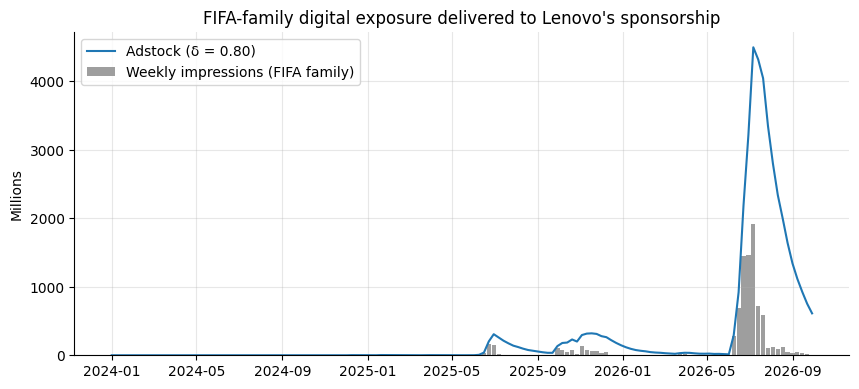

,Total impressions (millions)
property_id,
motogp,"9,926.4"
f1,"6,096.6"
fwc,"4,788.0"
fifa,"3,495.1"
ducati,677.1
fcwc,386.6
carolina_hurricanes,305.0
fwwc,169.1
infantino,78.2


**Figure 1 and Table 1.** Exposure weeks 2024-01-01 to 2026-09-28; FIFA-family total 8.97 bn impressions. Digital and social only: broadcast audiences are not measured.

In [2]:
fifa = ["fifa", "fwc", "fwwc", "fcwc", "fifae", "fifaewc", "infantino"]
weekly = adstock[adstock["property_id"].isin(fifa)].groupby("week")[["impressions", "adstock_impressions"]].sum()
fig, ax = plt.subplots()
ax.bar(weekly.index, weekly["impressions"] / 1e6, width=6, color="#9e9e9e", label="Weekly impressions (FIFA family)")
ax.plot(weekly.index, weekly["adstock_impressions"] / 1e6, color="tab:blue", label="Adstock (δ = 0.80)")
ax.set_ylabel("Millions"); ax.set_title("FIFA-family digital exposure delivered to Lenovo's sponsorship"); ax.legend(loc="upper left"); plt.show()
tot = adstock.groupby("property_id")["impressions"].sum().sort_values(ascending=False)
display((tot / 1e6).rename("Total impressions (millions)").to_frame().style.format("{:,.1f}"))
md(f"**Figure 1 and Table 1.** Exposure weeks {adstock['week'].min().date()} to {adstock['week'].max().date()}; "
   f"FIFA-family total {weekly['impressions'].sum()/1e9:.2f} bn impressions. Digital and social only: broadcast audiences are not measured.")

### 5.2 Survey lift by property and wave

In [3]:
panel = pd.read_parquet(E + "funnel_lift_exposure_panel.parquet")
view = panel[["reported_period", "property_id", "appeal_lift", "purchase_intent_lift", "funnel_lift_composite", "scale_version",
              "trailing_13w_adstock_mean", "brand_index_level_context", "model_eligible"]].rename(columns={
    "reported_period": "Wave", "property_id": "Property", "appeal_lift": "Appeal lift", "purchase_intent_lift": "Purchase-intent lift",
    "funnel_lift_composite": "Composite lift L", "scale_version": "Survey scale", "trailing_13w_adstock_mean": "13-week mean adstock",
    "brand_index_level_context": "Brand Index at wave", "model_eligible": "Comparable panel"})
display(view.style.format({"Appeal lift": lambda v: f"{100*v:.1f} pp", "Purchase-intent lift": lambda v: f"{100*v:.1f} pp", "Composite lift L": lambda v: f"{100*v:.1f} pp",
                           "13-week mean adstock": "{:,.0f}", "Brand Index at wave": "{:.1f}"}, na_rep="—").hide(axis="index"))
assoc = man["association_model"]
md(f"**Table 2.** {int(panel['model_eligible'].sum())} comparable property-wave observations (2025-plus survey scale). "
   f"Exposure–lift regression: **{assoc['status'].replace('_', ' ')}** ({assoc['reason']})")

Wave,Property,Appeal lift,Purchase-intent lift,Composite lift L,Survey scale,13-week mean adstock,Brand Index at wave,Comparable panel
2024-06,fwc,32.6 pp,28.1 pp,30.3 pp,2024_0_10,"393,918",102.2,False
2024-06,fwwc,34.5 pp,29.0 pp,31.8 pp,2024_0_10,0,102.2,False
2025-07,fwc,43.5 pp,35.5 pp,39.5 pp,2025plus_categorical,"268,821",113.0,True
2025-07,fwwc,48.3 pp,41.4 pp,44.9 pp,2025plus_categorical,0,113.0,True
2025-08,fcwc,45.4 pp,39.1 pp,42.2 pp,2025plus_categorical,"111,456,265",116.9,True
2026-02,fwc,44.7 pp,37.1 pp,40.9 pp,2025plus_categorical,"47,152,778",104.4,True
2026-04,fwwc,47.4 pp,40.0 pp,43.7 pp,2025plus_categorical,"1,355,110",126.1,True


**Table 2.** 5 comparable property-wave observations (2025-plus survey scale). Exposure–lift regression: **not estimable with current sample** (Only five comparable exposure-linked property-wave observations; no credible fixed-effects exposure-lift regression.)

### 5.3 Property allocation scenario

In [4]:
alloc = pd.read_parquet(E + "property_allocation_scenario.parquet")
display(alloc[["property_id", "survey_waves", "mean_funnel_lift", "mean_trailing_adstock", "allocation_share"]].rename(columns={
    "property_id": "Property", "survey_waves": "Comparable waves", "mean_funnel_lift": "Mean lift", "mean_trailing_adstock": "Mean 13-week adstock",
    "allocation_share": "Scenario share"}).style.format({"Mean lift": lambda v: f"{100*v:.1f} pp", "Mean 13-week adstock": "{:,.0f}", "Scenario share": "{:.1%}"}).hide(axis="index"))
top = alloc.sort_values("allocation_share", ascending=False).iloc[0]
md(f"**Table 3.** The largest scenario share goes to **{top['property_id'].upper()}** ({top['allocation_share']:.0%}). Mean lifts across properties: "
   f"{100*alloc['mean_funnel_lift'].min():.0f} to {100*alloc['mean_funnel_lift'].max():.0f} percentage points" + (", so the shares are driven by measured digital exposure, not by the survey." if alloc['mean_funnel_lift'].max() - alloc['mean_funnel_lift'].min() < 0.10 else "; both exposure and lift differences drive the shares."))

Property,Comparable waves,Mean lift,Mean 13-week adstock,Scenario share
fcwc,1,42.2 pp,"111,456,265",82.5%
fwc,2,40.2 pp,"23,710,799",17.0%
fwwc,2,44.3 pp,"677,555",0.5%


**Table 3.** The largest scenario share goes to **FCWC** (82%). Mean lifts across properties: 40 to 44 percentage points, so the shares are driven by measured digital exposure, not by the survey.

### 5.4 Valuation gate

In [5]:
g, cf, rs = man["valuation_gate"], man["counterfactual_gate"], man["royalty_schedule_gate"]
display(pd.DataFrame([
    ("Valuation", g["status"].replace("_", " "), ", ".join(g["missing_inputs"])),
    ("Counterfactual input (headline total effect)", cf["status"].replace("_", " "),
     f"lift {cf['candidate_delta_index_attrib']:+.2f} Brand Index points, placebo p = {cf['donor_placebo_p_value']:.3f}; "
     f"owner approval to use it: {cf['use_counterfactual_candidate']}; used for valuation: {cf['used_for_valuation']}"),
    ("Royalty schedule", rs["status"].replace("_", " "), f"{rs['available_points']} approved points; schedule status {rs['schedule_status'].replace('_', ' ')}"),
], columns=["Gate", "Status", "Detail"]).style.hide(axis="index"))
md(f"**Table 4.** Monetary rows produced: **{man['outputs']['monetization_rows']}**. {g['rule']}")

Gate,Status,Detail
Valuation,blocked missing explicit inputs,"delta_index_attrib, royalty_bps_per_index_point, brand_attributable_revenue, sponsorship_fee, discount_rate, persistence_years"
Counterfactual input (headline total effect),passes primary placebo test,"lift +7.48 Brand Index points, placebo p = 0.071; owner approval to use it: False; used for valuation: False"
Royalty schedule,blocked schedule not approved,0 approved points; schedule status pending client calibration


**Table 4.** Monetary rows produced: **0**. No monetary values are emitted until all required inputs are explicit.

## 6. Interpretation

In [6]:
md(f"""- **Exposure:** the sponsorship delivered {weekly['impressions'].sum()/1e9:.2f} bn measured FIFA-family digital impressions; the adstock series is the exposure
  input to the total effect and World Cup notebooks.
- **Survey:** the share of sponsorship-aware respondents rating Lenovo appealing or intending to buy is {100*alloc['mean_funnel_lift'].min():.0f}–{100*alloc['mean_funnel_lift'].max():.0f}
  percentage points higher than among unaware respondents, across properties. This is an observational difference, consistent with a sponsorship mechanism but also with self-selection.
- **Allocation:** a scenario only; with {int(panel['model_eligible'].sum())} comparable observations no exposure–lift relationship can be estimated.
- **Valuation:** blocked. The missing inputs are listed in Table 4; the most binding are the approved royalty schedule and the sponsorship fee.""")

- **Exposure:** the sponsorship delivered 8.97 bn measured FIFA-family digital impressions; the adstock series is the exposure
  input to the total effect and World Cup notebooks.
- **Survey:** the share of sponsorship-aware respondents rating Lenovo appealing or intending to buy is 40–44
  percentage points higher than among unaware respondents, across properties. This is an observational difference, consistent with a sponsorship mechanism but also with self-selection.
- **Allocation:** a scenario only; with 5 comparable observations no exposure–lift relationship can be estimated.
- **Valuation:** blocked. The missing inputs are listed in Table 4; the most binding are the approved royalty schedule and the sponsorship fee.

## 7. Limitations and non-claims

- **Observational lift.** Aware-minus-unaware differences are not causal effects.
- **Digital exposure only.** Broadcast audiences are absent, so properties with large TV reach are under-weighted.
- **Assumed decay.** δ = 0.80 is fixed, not estimated.
- **Proxied dates.** Survey fieldwork dates are reported months, aligned to month-end.
- **Counterfactual input needs owner approval.** The gate reads the headline total effect (`sponsorship_total_effect_v1`, ADR-0041). Even when its placebo test passes, the lift is only used once the owner sets `use_counterfactual_candidate` to true.
- **No money from exposure (P1).** Impressions and media value never enter valuation as monetary amounts.

## Next steps

1. Obtain the approved royalty schedule, sponsorship fee, brand-attributable revenue, discount rate and persistence horizon.
2. Owner decision on approving the headline lift as the valuation input.
3. Obtain exact survey fieldwork dates and Blinkfire data after the latest supplied week.